# Triton Kernel Development on AMD Instinct GPUs

Welcome to our AI Academy course! [OpenAI Triton](https://github.com/triton-lang/triton) is a Python-based programming language and compiler that makes it easy to write highly efficient GPU kernels with performance comparable to hand-tuned HIP/CUDA code. This course will demonstrate how to develop Triton Kernel on AMD Instinct GPUs. 


## Set up Triton development enviroment 
In this course, we will use a pre-built ROCm PyTorch image, which already integrates PyTorch with the AMD ROCm software stack. This provides a ready-to-use environment for development. Developers may also choose to use other ROCm base images if needed.

### Step1: Access AMD MI GPU 
We will use the **Instinct GPU** cloud instance from AMD Developer Cloud. You can register and create your account [here](https://amd.digitalocean.com/) to access the GPU instance.


### Step2: Install OpenAI Triton

#### 1. Uninstall the old Triton
It is highly recommended to use the latest version of Triton in your project, as AMD and other vendors continuously update optimization passes and algorithms in [OpenAI Triton](https://github.com/triton-lang/triton), which can significantly improve kernel performance.

Uninstall the existing triton by:


In [1]:
!pip uninstall -y triton

Found existing installation: triton 3.4.0
Uninstalling triton-3.4.0:
  Successfully uninstalled triton-3.4.0


#### 2. Install OpenAI Triton from source codes
The detailed steps to install Triton have been listed here. For any questions or issues encountered during the build, please report them on [Triton Issues](https://github.com/triton-lang/triton/issues).   

In [2]:
%%bash
# Remove existing Triton folder if it exists
if [ -d "triton" ]; then
    echo "Removing existing triton directory..."
    rm -rf triton
fi

# Clone Triton repo
git clone https://github.com/triton-lang/triton.git

# Install dependencies and Triton from source (non-editable install)
cd triton
pip install -r python/requirements.txt
pip install .

pip install matplotlib

Cloning into 'triton'...



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python3.12 -m pip install --upgrade pip


Processing /workspace/triton
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for triton: filename=triton-3.6.0+git53b0eafd-cp312-cp312-linux_x86_64.whl size=354134623 sha256=68ba8f3540d8edc24354b150f4c15ddc78b0d70e322c24a6bbaaefb6bd77e22a
  Stored in directory: /tmp/pip-ephem-wheel-cache-nxc1uuem/wheels/69/41/79/fad276bde3b7a95ae531600f8667549e64ae6068b28281555a
Successfully built triton



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python3.12 -m pip install --upgrade pip


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 45.3 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 122.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.4 MB/s  0:00:00
  Attempting uninstall: pyparsing
    Found existing installation: pyparsing 2.4.7
    Uninstalling pyparsing-2.4.7:
      Successfully uninstalled pyparsing-2.4.7
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Develop your first triton kernel on AMD Instinct GPUs

Vector addition is about as simple as it gets in GPU programming. We have two input arrays, let’s say x and y, and we want to compute an output array z where each element is just the sum: z[i] = x[i] + y[i].


### Naive Vector Add Kernel

In Triton, we implement this by writing a kernel function. The kernel is decorated with @triton.jit, which means Triton will compile it into GPU code. Inside the kernel, we calculate which block of elements this program instance is responsible for, load those elements from memory, perform the addition, and then write the result back to memory.

The naïve kernel looks something like this:

In [3]:
import torch
import triton
import triton.language as tl


@triton.jit
def add_kernel(x_ptr,  # *Pointer* to first input vector.
               y_ptr,  # *Pointer* to second input vector.
               output_ptr,  # *Pointer* to output vector.
               n_elements,  # Size of the vector.
               BLOCK_SIZE: tl.constexpr,  # Number of elements each program should process.
               # NOTE: `constexpr` so it can be used as a shape value.
               ):
    # There are multiple 'programs' processing different data. We identify which program
    # we are here:
    pid = tl.program_id(axis=0)  # We use a 1D launch grid so axis is 0.
    # This program will process inputs that are offset from the initial data.
    # For instance, if you had a vector of length 256 and block_size of 64, the programs
    # would each access the elements [0:64, 64:128, 128:192, 192:256].
    # Note that offsets is a list of pointers:
    block_start = pid * BLOCK_SIZE
    offsets = block_start + tl.arange(0, BLOCK_SIZE)
    # Create a mask to guard memory operations against out-of-bounds accesses.
    mask = offsets < n_elements
    # Load x and y from DRAM, masking out any extra elements in case the input is not a
    # multiple of the block size.
    x = tl.load(x_ptr + offsets, mask=mask)
    y = tl.load(y_ptr + offsets, mask=mask)
    output = x + y
    # Write x + y back to DRAM.
    tl.store(output_ptr + offsets, output, mask=mask) 

Here’s what happens:
- tl.program_id(0) gives us the current block index along the first axis.
- tl.arange(0, BLOCK_SIZE) generates indices within the block.
- With those offsets, we load chunks of x and y, add them, and write the result to z.
- Finally, the mask ensures we don’t read out of bounds if the vector size isn’t a perfect multiple of the block size.

This is as straightforward as it gets. It’s basically the Triton equivalent of a textbook GPU kernel.


Next, let's see how to invoke our kernel. We will define a wrapper function to perform vector addition on the GPU using Triton. It preallocates an output tensor, checks that all tensors are on the same device, and calculates the total number of elements. A 1D launch grid is defined so the workload is divided into blocks, each processing `BLOCK_SIZE` elements in parallel. The Triton kernel add_kernel is then launched asynchronously, computing z = x + y across all elements. Finally, the function returns the output tensor, which may still be computing on the GPU until synchronization.

In [4]:
def add(x: torch.Tensor, y: torch.Tensor):
    # We need to preallocate the output.
    output = torch.empty_like(x)
    assert x.device == y.device and output.device == y.device
    n_elements = output.numel()
    # The SPMD launch grid denotes the number of kernel instances that run in parallel.
    # It is analogous to CUDA launch grids. It can be either Tuple[int], or Callable(metaparameters) -> Tuple[int].
    # In this case, we use a 1D grid where the size is the number of data divide block size:
    grid = lambda meta: (triton.cdiv(n_elements, meta['BLOCK_SIZE']), )
    # NOTE:
    #  - Each torch.tensor object is implicitly converted into a pointer to its first element.
    #  - `triton.jit`'ed functions can be indexed with a launch grid to obtain a callable GPU kernel.
    #  - Don't forget to pass meta-parameters as keywords arguments.
    add_kernel[grid](x, y, output, n_elements, BLOCK_SIZE=64)
    # We return a handle to z but, since `torch.cuda.synchronize()` hasn't been called, the kernel is still
    # running asynchronously at this point.
    return output

We then compare the above kernel's compute result with torch, to test its correctness:

In [5]:
torch.manual_seed(0)
size = 8192
x = torch.rand(size, device="cuda:0")
y = torch.rand(size, device="cuda:0")
output_torch = x + y
output_triton = add(x, y)
print(output_torch)
print(output_triton)
print(f'The maximum difference between torch and triton is '
      f'{torch.max(torch.abs(output_torch - output_triton))}')
torch.allclose(output_torch, output_triton, atol=1e-3, rtol=1e-3)

tensor([1.3713, 1.3076, 0.4940,  ..., 0.2920, 1.5087, 0.9388], device='cuda:0')
tensor([1.3713, 1.3076, 0.4940,  ..., 0.2920, 1.5087, 0.9388], device='cuda:0')
The maximum difference between torch and triton is 0.0


True

If no error occurs, we are good to go!

#### Benchmark the Naive Vector Add Kernel

The general benchmarking process is simple:
- Create random input tensors x and y on the GPU.
- Allocate an output tensor z.
- Launch our Triton kernel with a suitable grid size.
- Measure execution time using torch.cuda.synchronize() to make sure the GPU work is complete before timing stops

This code here benchmarks the Triton-based vector addition kernel by using triton's utility. It uses triton.testing.perf_report to sweep over different input sizes (from 
2^12 to 2^27) and measure kernel latency. Random input tensors x and y are created on the target device, and the add function (which wraps the Triton kernel) is timed with triton.testing.do_bench. The results (median, min, and max latency in milliseconds) are collected and converted into effective memory bandwidth, producing a performance report that shows how execution bandwidth scales with input size.

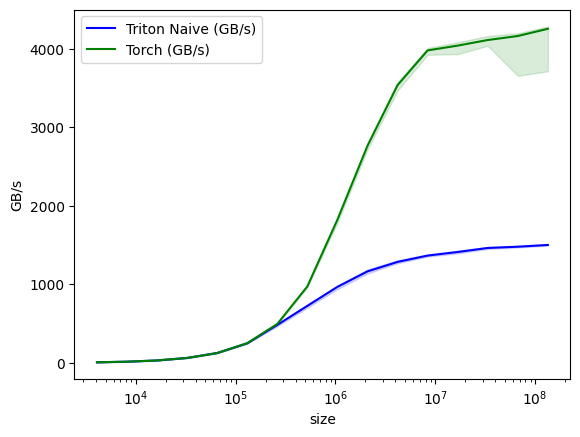

vector-add-performance:
           size  Triton Naive (GB/s)  Torch (GB/s)
0        4096.0             7.961127      8.118930
1        8192.0            16.026084     16.237859
2       16384.0            31.844509     31.639525
3       32768.0            63.689019     63.689019
4       65536.0           126.558098    125.748638
5      131072.0           249.859245    251.497277
6      262144.0           484.330726    496.563217
7      524288.0           726.580010    974.663978
8     1048576.0           968.661452   1824.668243
9     2097152.0          1165.651036   2765.475051
10    4194304.0          1286.300386   3536.512564
11    8388608.0          1366.816456   3979.101054
12   16777216.0          1412.580242   4039.944309
13   33554432.0          1463.842137   4111.097087
14   67108864.0          1479.585110   4162.220221
15  134217728.0          1501.932819   4254.341315


In [6]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'],  # Argument names to use as an x-axis for the plot.
        x_vals=[2**i for i in range(12, 28, 1)],  # Different possible values for `x_name`.
        x_log=True,  # x axis is logarithmic.
        line_arg='provider',  # Argument name whose value corresponds to a different line in the plot.
        line_vals=['triton naive', 'torch'],  # Possible values for `line_arg`.
        line_names=['Triton Naive', 'Torch'],  # Label name for the lines.
        styles=[('blue', '-'), ('green', '-')],  # Line styles.
        ylabel='GB/s',  # Label name for the y-axis.
        plot_name='vector-add-performance',  # Name for the plot. Used also as a file name for saving the plot.
        args={},  # Values for function arguments not in `x_names` and `y_name`.
    ))
def benchmark(size, provider):
    x = torch.rand(size, device="cuda:0", dtype=torch.float32)
    y = torch.rand(size, device="cuda:0", dtype=torch.float32)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: x + y, quantiles=quantiles)
    if provider == 'triton naive':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: add(x, y), quantiles=quantiles)
    gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    # return measured bandwidth of the kernel
    return gbps(ms), gbps(max_ms), gbps(min_ms)

benchmark.run(print_data=True, show_plots=True)

### Optimize the Vector Add Kernel with Triton Autotune

The bottleneck for vector addition is not arithmetic but memory: we are moving large amounts of data from GPU memory, performing a single addition, and writing the result back. As a result, memory bandwidth dominates performance. To optimize such a kernel, we need to carefully design the launch configuration:

1. Use larger block sizes so that each program instance handles more elements and memory accesses are coalesced.

2. Assign multiple warps per block to maximize parallelism and keep the GPU fully utilized.

3. Ensure efficient grid mapping so that all elements are covered without unnecessary overhead.

For example, increasing `BLOCK_SIZE` from 128 to 1024 can improve performance, and Triton’s grid function makes it straightforward to scale across all elements. However, the optimal choice of these meta-parameters (like `BLOCK_SIZE` or number of warps) depends heavily on the input size and the GPU architecture. A configuration that works well for small arrays may underperform on larger ones, and vice versa.

To deal with this variability, Triton provides an autotuning mechanism. Autotuning allows us to specify multiple candidate configurations and lets Triton automatically benchmark them to select the best one for the given workload and hardware.

#### Adding Autotune to the Kernel

To enable autotuning, we decorate our kernel with `@triton.autotune`. The decorator takes a list of triton.Config objects, each representing a candidate configuration, and a set of keys (key) that determine when a kernel should be re-autotuned.

Here’s how we can apply it to our add_kernel:


In [7]:
import triton
import triton.language as tl

DEVICE = "cuda:0"
@triton.autotune(
    configs=[
        triton.Config({"BLOCK_SIZE": 128}, num_warps=2),
        triton.Config({"BLOCK_SIZE": 256}, num_warps=4),
        triton.Config({"BLOCK_SIZE": 512}, num_warps=4),
        triton.Config({"BLOCK_SIZE": 1024}, num_warps=8),
    ],
    key=["n_elements"],  # re-autotune when problem size changes
)
@triton.jit
def optimized_add_kernel(x_ptr,  # *Pointer* to first input vector.
               y_ptr,  # *Pointer* to second input vector.
               output_ptr,  # *Pointer* to output vector.
               n_elements,  # Size of the vector.
               BLOCK_SIZE: tl.constexpr,  # Number of elements each program should process.
               # NOTE: `constexpr` so it can be used as a shape value.
               ):
    pid = tl.program_id(axis=0)
    block_start = pid * BLOCK_SIZE
    offsets = block_start + tl.arange(0, BLOCK_SIZE)
    mask = offsets < n_elements
    x = tl.load(x_ptr + offsets, mask=mask)
    y = tl.load(y_ptr + offsets, mask=mask)
    output = x + y
    tl.store(output_ptr + offsets, output, mask=mask) 

Compared to the naive kernel, the key difference is the @triton.autotune decorator, which instructs Triton to try different block sizes and pick the fastest one.

#### Update the Python Wrapper
We now need a Python wrapper to launch the autotuned kernel. This implementation is almost identical to the previous one, with two differences:
1. The wrapper function is named as optimized_add. 
2. The optimized_add_kernel function does not include a BLOCK_SIZE parameter in its argument list.

In [8]:
def optimized_add(x: torch.Tensor, y: torch.Tensor):
    # We need to preallocate the output.
    output = torch.empty_like(x)
    assert x.device == y.device and output.device == y.device
    n_elements = output.numel()
    # The SPMD launch grid denotes the number of kernel instances that run in parallel.
    # It is analogous to CUDA launch grids. It can be either Tuple[int], or Callable(metaparameters) -> Tuple[int].
    # In this case, we use a 1D grid where the size is the number of data divide block size:
    grid = lambda meta: (triton.cdiv(n_elements, meta['BLOCK_SIZE']), )
    # NOTE:
    #  - Each torch.tensor object is implicitly converted into a pointer to its first element.
    #  - `triton.jit`'ed functions can be indexed with a launch grid to obtain a callable GPU kernel.
    optimized_add_kernel[grid](x, y, output, n_elements)
    # We return a handle to z but, since `torch.cuda.synchronize()` hasn't been called, the kernel is still
    # running asynchronously at this point.
    return output

#### Benchmark the Autotuned Kernel
Let’s compare the performance of our naive kernel and the autotuned kernel side by side using the same benchmarking harness:

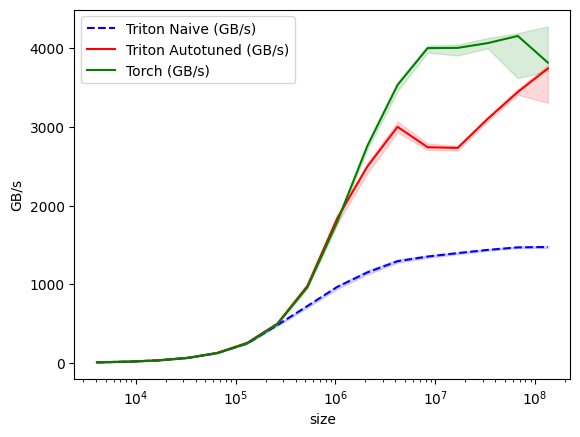

vector-add-performance:
           size  Triton Naive (GB/s)  Triton Autotuned (GB/s)  Torch (GB/s)
0        4096.0             8.013042                 8.065639      8.118930
1        8192.0            16.026084                16.026084     16.133924
2       16384.0            31.639525                32.052168     31.634433
3       32768.0            63.689019                64.104335     63.279049
4       65536.0           124.949476               127.378037    125.748638
5      131072.0           248.281608               256.417340    249.898953
6      262144.0           481.366170               499.797906    493.524937
7      524288.0           723.155852               980.741359    962.732339
8     1048576.0           968.661452              1846.355400   1803.743111
9     2097152.0          1151.754001              2500.827183   2765.171396
10    4194304.0          1294.271962              3003.439943   3536.512564
11    8388608.0          1352.819479              2744.140182   

In [9]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'],  # Argument names to use as an x-axis for the plot.
        x_vals=[2**i for i in range(12, 28, 1)],  # Different possible values for `x_name`.
        x_log=True,  # x axis is logarithmic.
        line_arg='provider',  # Argument name whose value corresponds to a different line in the plot.
        line_vals=['triton naive', 'triton autotuned', 'torch'],  # Possible values for `line_arg`.
        line_names=['Triton Naive', 'Triton Autotuned', 'Torch'],  # Label name for the lines.
        styles=[('blue', '--'), ('red', '-'), ('green', '-')],  # Line styles.
        ylabel='GB/s',  # Label name for the y-axis.
        plot_name='vector-add-performance',  # Name for the plot. Used also as a file name for saving the plot.
        args={},  # Values for function arguments not in `x_names` and `y_name`.
    ))
def benchmark(size, provider):
    x = torch.rand(size, device=DEVICE, dtype=torch.float32)
    y = torch.rand(size, device=DEVICE, dtype=torch.float32)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: x + y, quantiles=quantiles)
    if provider == 'triton naive':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: add(x, y), quantiles=quantiles)
    if provider == 'triton autotuned':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: optimized_add(x, y), quantiles=quantiles)
    gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    # return measured bandwidth of the kernel
    return gbps(ms), gbps(max_ms), gbps(min_ms)


benchmark.run(print_data=True, show_plots=True)

This benchmark will generate a plot comparing all versions across input sizes, clearly showing the benefit of autotuning.

## Experiment with Reduce Kernel and Optimized Version

Now that we’ve explored vector addition, let’s move on to another very important building block in GPU programming: reductions. Reductions are operations where we take a large set of numbers and combine them into fewer results—often just one. The simplest example is summing all the elements of a vector. This kind of operation is everywhere in deep learning: computing losses, aggregating gradients, or even in attention mechanisms. The naive implementation is look like this:


Now, we’ll write a naïve reduction kernel in Triton, benchmark it, and then create an optimized version that uses shared memory and parallelism more effectively. Finally, we’ll compare the performance.

### Naive Reduction Kernel

The high-level idea:
- Each program instance reads a single element from the input.
- Then we somehow add them all up into a single scalar.

The problem here is obvious: if every thread just writes to the same memory location, we get race conditions. To keep things simple, the naïve version can do something like:
- Assign each block to sum a chunk of the input.
- Write that partial sum into an output buffer.
- Then reduce the buffer on the CPU or with another kernel.

The naive version might look like this:


In [10]:
import torch
import triton
import triton.language as tl

DEVICE = "cuda:0"

@triton.jit
def reduce_kernel(
    x_ptr,  
    output_ptr,  
    n_elements,  
    BLOCK_SIZE: tl.constexpr,
):
    pid = tl.program_id(axis=0)
    block_start = pid * BLOCK_SIZE
    
    # serial add at intra block
    acc = 0.0
    for i in range(BLOCK_SIZE):
        # check boundary
        if (block_start + i) < n_elements:
            offset = block_start + i
            mask = offset < n_elements
            # accumulate
            acc += tl.load(x_ptr + block_start + i, mask=mask)
    
    # atomic to write back result of each block
    tl.atomic_add(output_ptr, acc)

Wrap the reduce_kernel with below function:

In [11]:
def reduce(x, BLOCK_SIZE=1024):
    assert x.is_cuda, "x must on GPU"
    n_elements = x.numel()
    # calc block numbers we need
    grid = lambda meta: (triton.cdiv(n_elements, meta['BLOCK_SIZE']),)
    # alloc output buffer
    output = torch.zeros(1, device=x.device, dtype=x.dtype)
    # launch kernel
    reduce_kernel[grid](x, output, n_elements, BLOCK_SIZE=BLOCK_SIZE)
    return output

Compare above kernel's compute result with torch's, to test its correctness:

In [12]:
torch.manual_seed(0)
size = 1024
x = torch.rand(size, device="cuda:0")
output_torch = x.sum()
output_triton = reduce(x)
print(output_torch)
print(output_triton)
print(f'The maximum difference between torch and triton is '
      f'{torch.max(torch.abs(output_torch - output_triton))}')
torch.allclose(output_torch, output_triton, atol=1e-3, rtol=1e-3)

tensor(520.5516, device='cuda:0')
tensor([520.5516], device='cuda:0')
The maximum difference between torch and triton is 0.0


True

#### Benchmark Naive Reduction Kernel
 The benchmark way is same as we used in vector add kernel.

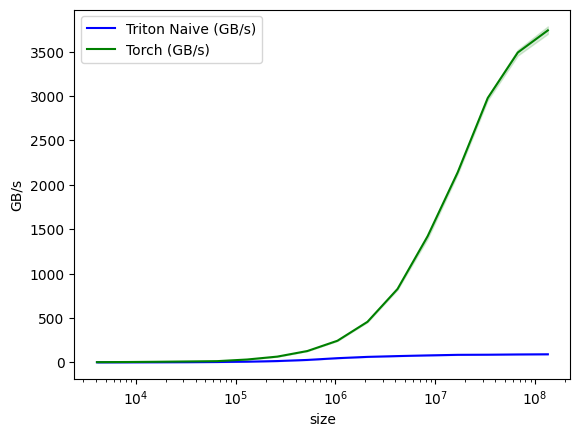

reduce-performance:
           size  Triton Naive (GB/s)  Torch (GB/s)
0        4096.0             0.249190      2.185407
1        8192.0             0.466249      3.801392
2       16384.0             0.948189      6.461205
3       32768.0             1.864997      9.907181
4       65536.0             3.719357     13.537699
5      131072.0             7.386263     32.052820
6      262144.0            14.546584     64.579417
7      524288.0            27.230081    127.579512
8     1048576.0            46.956596    243.303199
9     2097152.0            61.649211    456.846081
10    4194304.0            70.616825    827.034235
11    8388608.0            78.212543   1420.954995
12   16777216.0            84.677443   2140.497172
13   33554432.0            85.987868   2978.446341
14   67108864.0            88.970629   3490.935185
15  134217728.0            90.880454   3740.556883


In [13]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'],  # Argument names to use as an x-axis for the plot.
        x_vals=[2**i for i in range(12, 28, 1)],  # Different possible values for `x_name`.
        x_log=True,  # x axis is logarithmic.
        line_arg='provider',  # Argument name whose value corresponds to a different line in the plot.
        line_vals=['triton naive', 'torch'],  # Possible values for `line_arg`.
        line_names=['Triton Naive', 'Torch'],  # Label name for the lines.
        styles=[('blue', '-'), ('green', '-')],  # Line styles.
        ylabel='GB/s',  # Label name for the y-axis.
        plot_name='reduce-performance',  # Name for the plot. Used also as a file name for saving the plot.
        args={},  # Values for function arguments not in `x_names` and `y_name`.
    ))
def benchmark(size, provider):
    x = torch.rand(size, device=DEVICE, dtype=torch.float32)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: x.sum(), quantiles=quantiles)
    if provider == 'triton naive':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: reduce(x), quantiles=quantiles)
    gbps = lambda ms: x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    # return measured bandwidth of the kernel
    return gbps(ms), gbps(max_ms), gbps(min_ms)

benchmark.run(print_data=True, show_plots=True)

From the benchmark data and plot, we can see that the naïve reduction kernel is noticeably slower. That’s expected — this implementation didn't not exploit GPU's parallelism.

### Optimize Reduction Kernel with Block-Level Reduction and Autotune

Instead of doing accumulation per element inside the block, we can use block-local reduction. This so-called tree-based reduction leverages Triton's built-in tl.sum, which implements a tree-based reduction pattern: values are progressively summed in parallel until one scalar remains.

Besides the block-level reduction, autotune is also adopted to help us to get better `BLOCK_SIZE` option to improve performance.

In [14]:
@triton.autotune(
    configs=[
        triton.Config({"BLOCK_SIZE": 128}, num_warps=2),
        triton.Config({"BLOCK_SIZE": 256}, num_warps=4),
        triton.Config({"BLOCK_SIZE": 512}, num_warps=4),
        triton.Config({"BLOCK_SIZE": 512}, num_warps=8),
        triton.Config({"BLOCK_SIZE": 1024}, num_warps=8),
        triton.Config({"BLOCK_SIZE": 2048}, num_warps=8),
        triton.Config({"BLOCK_SIZE": 4096}, num_warps=8),
        triton.Config({"BLOCK_SIZE": 8192}, num_warps=8),
        triton.Config({"BLOCK_SIZE": 16384}, num_warps=8),
        triton.Config({"BLOCK_SIZE": 32768}, num_warps=8),
        triton.Config({"BLOCK_SIZE": 65536}, num_warps=8),
    ],
    key=["n_elements"],  # re-autotune when problem size changes
)        
@triton.jit
def reduce_kernel_optimized(x_ptr, out_ptr, n_elements,
                  BLOCK_SIZE: tl.constexpr):
    pid   = tl.program_id(0)
    offset = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)
    mask   = offset < n_elements
    x = tl.load(x_ptr + offset, mask=mask, other=0.0)

    # call tree-based high performance reduce algorithm
    block_sum = tl.sum(x, axis=0)

    tl.atomic_add(out_ptr, block_sum)

def reduce_optimized(x, BLOCK_SIZE=1024):
    assert x.is_cuda
    out = torch.zeros(1, device=x.device, dtype=x.dtype)
    grid = lambda meta: (triton.cdiv(x.numel(), meta['BLOCK_SIZE']),)
    reduce_kernel_optimized[grid](x, out, x.numel())
    return out

#### Benchmark the Optimied Reduction Kernel
Let’s compare the performance of our naive kernel and the optimized kernel side by side using the same benchmarking harness:

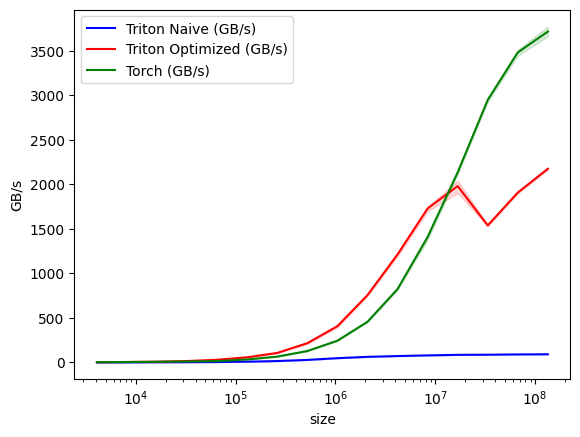

reduce-performance:
           size  Triton Naive (GB/s)  Triton Optimized (GB/s)  Torch (GB/s)
0        4096.0             0.247078                 1.866059      2.185407
1        8192.0             0.470541                 3.801833      3.766870
2       16384.0             0.935694                 7.396839      6.461205
3       32768.0             1.911897                14.928474      9.877317
4       65536.0             3.719410                28.931022     13.509792
5      131072.0             7.400912                56.612461     32.289709
6      262144.0            14.603309               105.895370     64.579417
7      524288.0            27.244585               215.269141    127.269813
8     1048576.0            46.956596               407.055892    243.289083
9     2097152.0            61.868364               755.390182    455.877817
10    4194304.0            70.748447              1213.015414    823.785524
11    8388608.0            78.278411              1729.253379   1409

In [15]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'],  # Argument names to use as an x-axis for the plot.
        x_vals=[2**i for i in range(12, 28, 1)],  # Different possible values for `x_name`.
        x_log=True,  # x axis is logarithmic.
        line_arg='provider',  # Argument name whose value corresponds to a different line in the plot.
        line_vals=['triton naive', 'triton optimized', 'torch'],  # Possible values for `line_arg`.
        line_names=['Triton Naive', 'Triton Optimized', 'Torch'],  # Label name for the lines.
        styles=[('blue', '-'), ('red', '-'), ('green', '-')],  # Line styles.
        ylabel='GB/s',  # Label name for the y-axis.
        plot_name='reduce-performance',  # Name for the plot. Used also as a file name for saving the plot.
        args={},  # Values for function arguments not in `x_names` and `y_name`.
    ))
def benchmark(size, provider):
    x = torch.rand(size, device=DEVICE, dtype=torch.float32)
    y = torch.rand(size, device=DEVICE, dtype=torch.float32)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: x.sum(), quantiles=quantiles)
    if provider == 'triton naive':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: reduce(x), quantiles=quantiles)
    if provider == 'triton optimized':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: reduce_optimized(x), quantiles=quantiles)
    gbps = lambda ms: x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    # return measured bandwidth of the kernel
    return gbps(ms), gbps(max_ms), gbps(min_ms)

benchmark.run(print_data=True, show_plots=True)

This benchmark will generate a plot comparing all versions across input sizes, clearly showing the benefit of optimization.

## Summary
Through this course, developer has already know how to develop and optimize Triton kernel on AMD Instinct GPUs. If developer would like to study more about OpenAI Triton itself, OpenAI Triton [official document](https://triton-lang.org/main/index.html) can be very useful. You can find more information about AMD Triton from [this document](https://rocm.docs.amd.com/en/latest/how-to/rocm-for-ai/inference-optimization/optimizing-triton-kernel.html) and [this blog](https://rocm.blogs.amd.com/software-tools-optimization/kernel-development-optimizations-with-triton-on-/README.html). We hope that this course will encourage you to develop, test, and tune Triton kernels on AMD Instinct GPUs, and help us shape the future of AI acceleration.   